In this notebook, we test our method on a simple CNN with 1x2 convolution and 1x4 images.

In [2]:
from Meta_learning import MetaLearner
import Meta_loss_functions as mlf
import torch
import torch.nn as nn
import torch.nn.functional as F

The parameters we will train are the dataset elements themselves. The model consists of a 1×2 convolution with stride (1×2), followed by max pooling and a linear layer.

In [3]:
class DatasetGenerator(nn.Module):
    def __init__(self, num_classes, n_per_class):
        super().__init__()
        self.data = nn.Parameter(
            0.1 * torch.randn(num_classes * n_per_class, 1, 1, 4)
        )

    def forward(self, z=None, y=None):
        return self.data

class CNN_1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Conv2d(1, 1, kernel_size=(1, 2), stride=(1, 2))
        self.pool = nn.MaxPool2d(kernel_size=(1, 2))
        self.fc = nn.Linear(1, num_classes)
        
    def forward(self, x):
        x = F.leaky_relu(self.conv(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

First try this with 2 classes and without any regularization term:

step: 147, meta_loss: 0.0297, accuracy: 100.00%


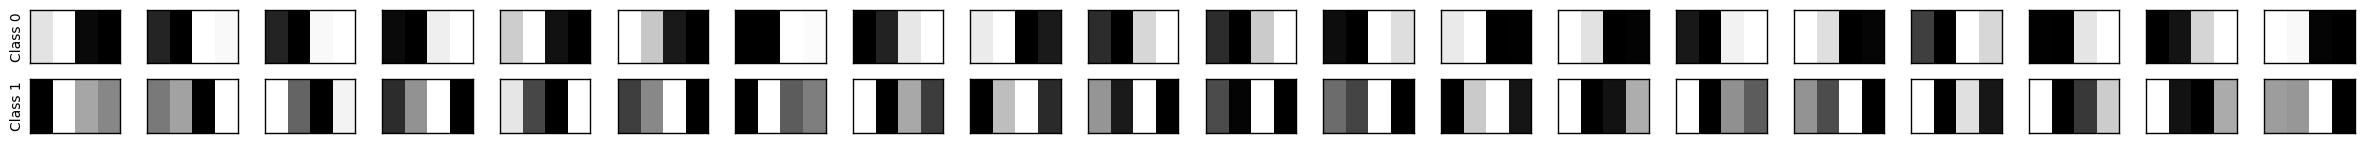

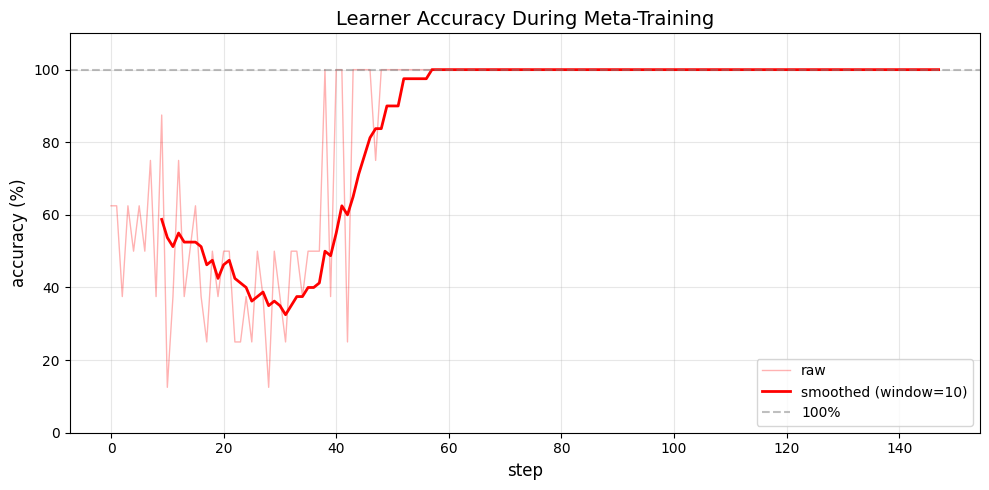

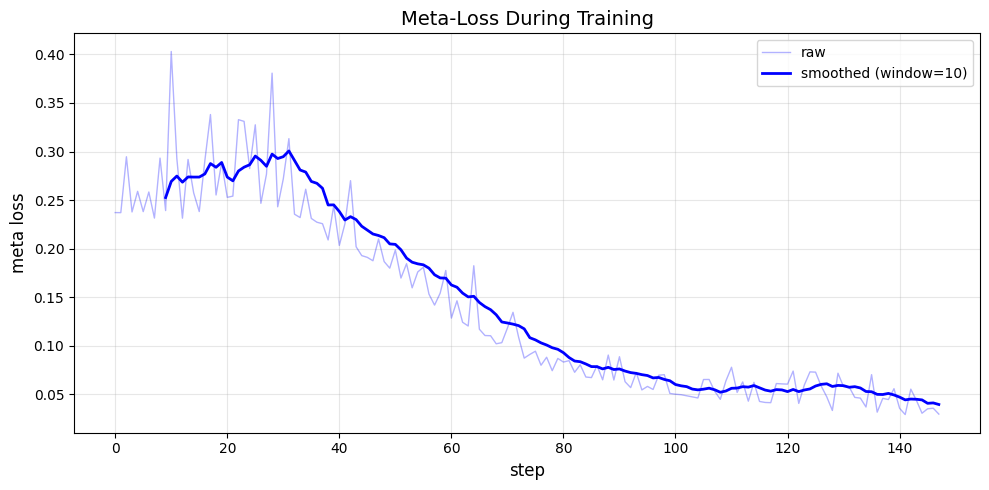

In [4]:
generator = DatasetGenerator(num_classes=2, n_per_class=20)

meta = MetaLearner(
    generator=generator,
    learner_class=CNN_1,
    meta_loss_fn=mlf.meta_loss_mse,
    num_classes=2,
    n_per_class=20,
    meta_lr=0.01,
    inner_lr=0.5, 
    inner_steps=5,
    stop_after_consecutive_100=100
)

meta.train(steps=1000, visualize_every=0)
meta.plot_accuracy()
meta.plot_meta_loss()

Even without regularization, the trivial solution (where all images within a class are identical) does not fully occur. This reveals the convolutional architecture's inductive bias towards locality — within a given class, we observe images where the first and second pairs of pixels are swapped. This indicates that for this architecture, local structure matters more than global structure.

Now, let us introduce regularization. We start with the average distance between classes.

step: 368, meta_loss: 0.0445, accuracy: 100.00%


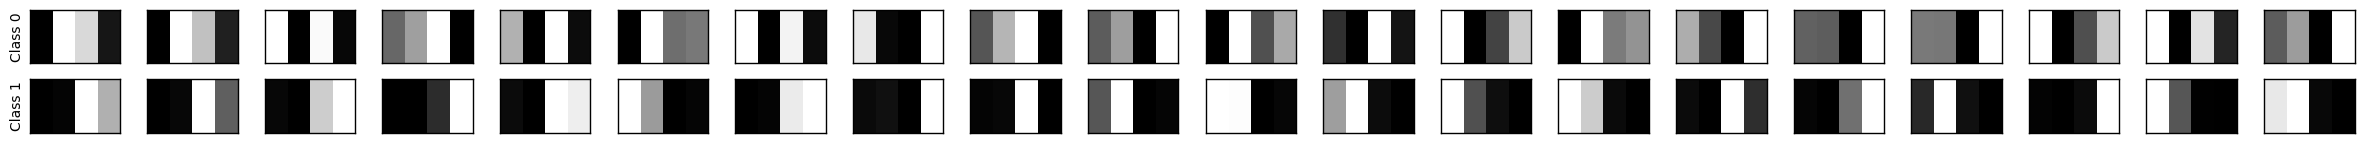

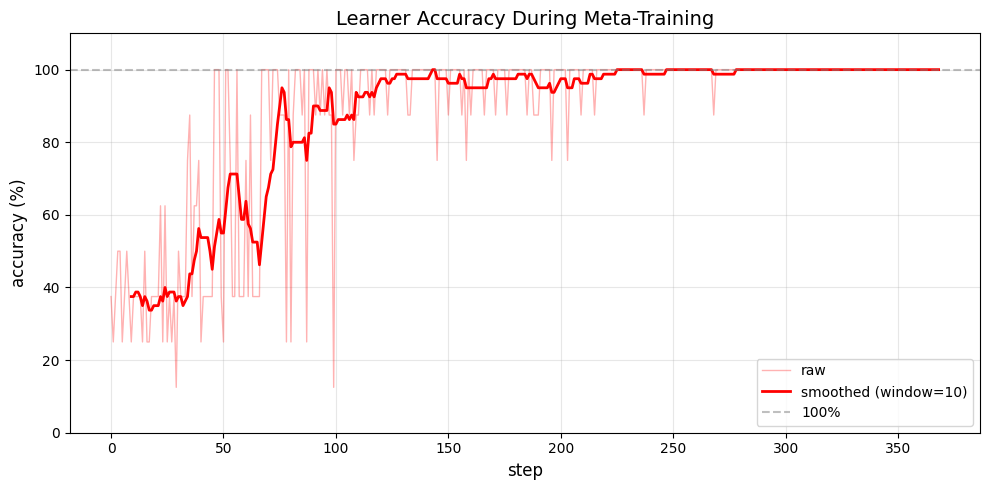

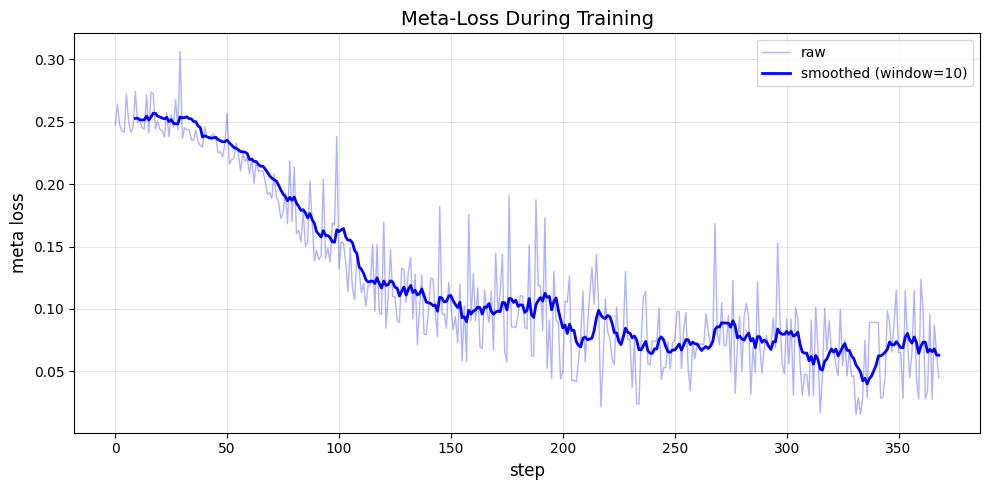

In [10]:
generator = DatasetGenerator(num_classes=2, n_per_class=20)

meta = MetaLearner(
    generator=generator,
    learner_class=CNN_1,
    meta_loss_fn=mlf.meta_loss_mse,
    num_classes=2,
    n_per_class=20,
    regularization_fn=mlf.regularizer_class_diversity,
    reg_parameter=0.01,
    meta_lr=0.01,
    inner_lr=0.5, 
    inner_steps=5,
    stop_after_consecutive_100=100
)

meta.train(steps=2000, visualize_every=0)
meta.plot_accuracy()
meta.plot_meta_loss()

As can be seen, the classes become more diverse while still preserving locality. In class 1, the defining pattern is two black pixels in one of the two positions, while the other position can contain anything — two white pixels, one white and one black, or vice versa. Moreover, the two black pixels may appear either in the left or the right pair. This reflects the inductive bias towards locality: the label is determined by the local structure rather than the global one. The effect of stride 2 is also noticeable — class 0 contains an element with two black pixels in the middle, but this pattern does not appear in class 1.

Now, we try penalizing the data matrix for small singular values.

step: 652, meta_loss: 0.0658, accuracy: 100.00%


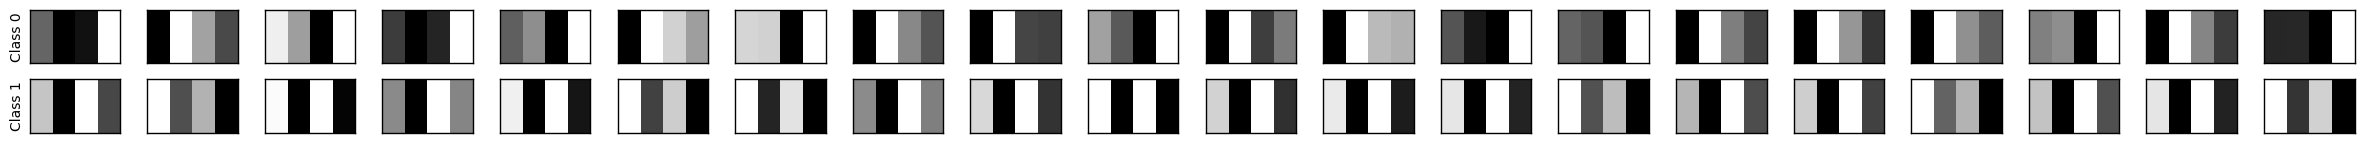

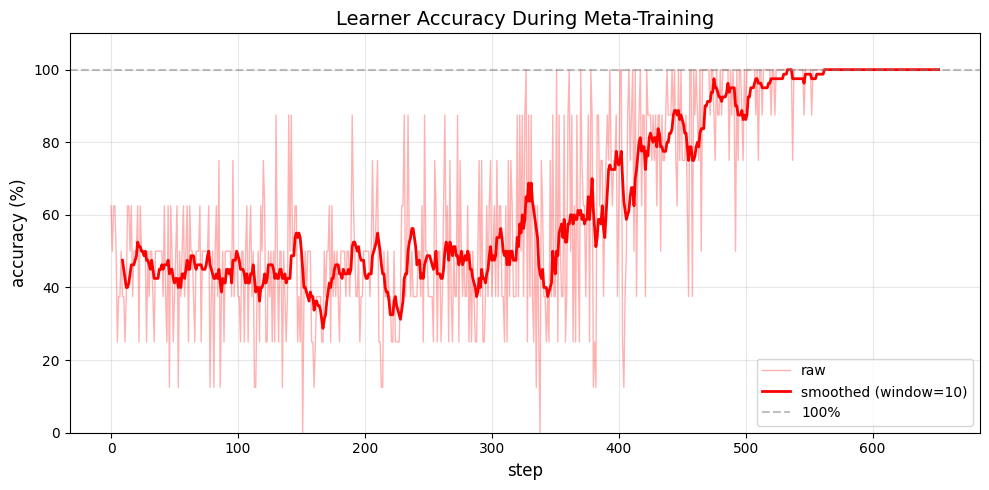

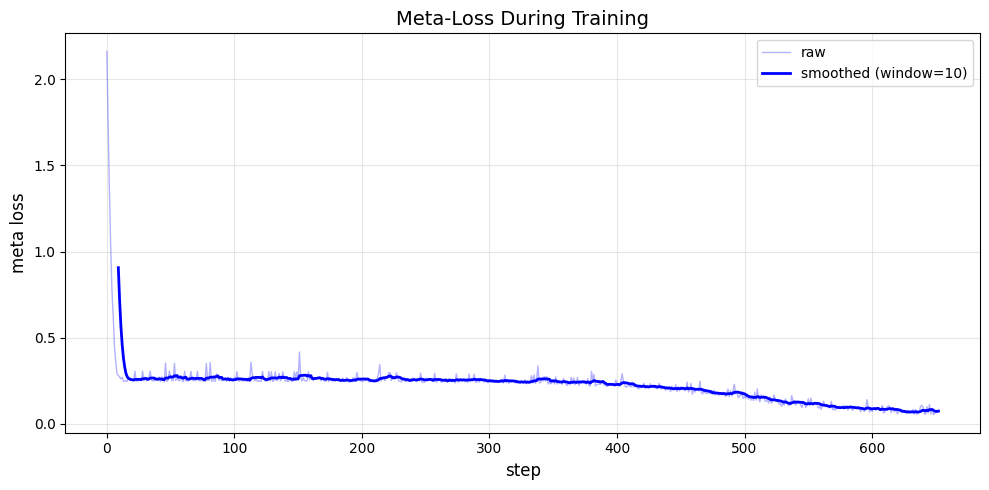

In [16]:
generator = DatasetGenerator(num_classes=2, n_per_class=20)

meta = MetaLearner(
    generator=generator,
    learner_class=CNN_1,
    meta_loss_fn=mlf.meta_loss_mse,
    num_classes=2,
    n_per_class=20,
    regularization_fn=mlf.regularizer_svd,
    reg_parameter=10,
    meta_lr=0.01,
    inner_lr=0.5, 
    inner_steps=5,
    stop_after_consecutive_100=100
)

meta.train(steps=2000, visualize_every=0)
meta.plot_accuracy()
meta.plot_meta_loss()

As can be seen, the situation is similar — here, the distinguishing pattern for class 0 consists of a black pixel followed by a white pixel (in that exact order).

Thus, using this toy example, we have shown that our algorithm trains the generator to create datasets that reflect the inductive bias of the model — in this case, the locality of the data.